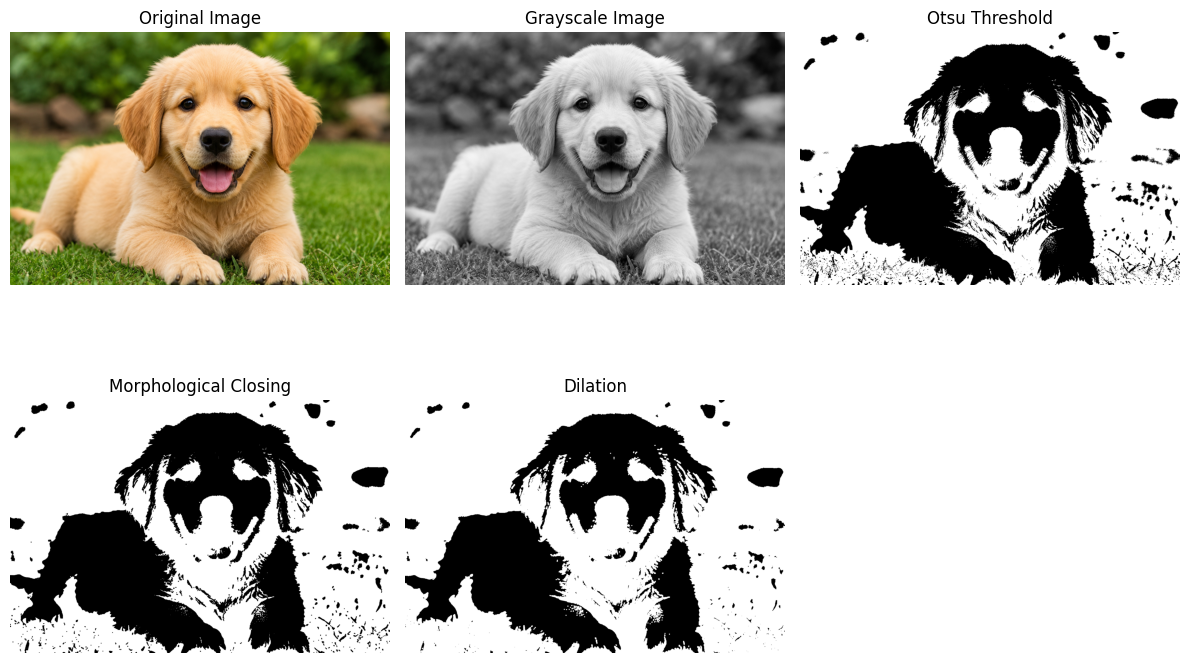

Output saved as dilation.png


In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read the uploaded image
img = cv2.imread('/content/dog.png')

# Check if the image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check the file path.")
else:
    # Convert BGR to RGB
    b, g, r = cv2.split(img)
    rgb_img = cv2.merge([r, g, b])

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Otsu Thresholding
    ret, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphological Closing
    kernel = np.ones((2, 2), np.uint8)
    closing = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Dilation
    sure_bg = cv2.dilate(closing, kernel, iterations=3)

    # Display Results
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(thresh, cmap="gray")
    plt.title("Otsu Threshold")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(closing, cmap="gray")
    plt.title("Morphological Closing")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(sure_bg, cmap="gray")
    plt.title("Dilation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Save output image
    cv2.imwrite("/content/dilation.png", sure_bg)
    print("Output saved as dilation.png")